In [1]:
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

In [2]:
df = pd.read_parquet('/Users/other/Documents/Sweet-Sense-AI/data/dataset/data.parquet')
df.head()

,isDiabetic,BMI,_RFBMI5,HighBP,HighChol,CholCheck,CHCKIDNY,Smoker,HvyAlcoholConsump,Stroke,...,Veggies,GenHlth,PhysHlth,MentHlth,DiffWalk,AnyHealthcare,NoDocbcCost,CHECKUP1,Sex,Age
0,0.0,40.0,2.0,1.0,1.0,1.0,2.0,1.0,0.0,0.0,...,1.0,5.0,15.0,18.0,1.0,1.0,0.0,1.0,0.0,9.0
1,0.0,25.0,2.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,...,0.0,3.0,0.0,0.0,0.0,0.0,1.0,4.0,0.0,7.0
2,0.0,28.0,2.0,1.0,1.0,1.0,2.0,0.0,0.0,0.0,...,0.0,5.0,30.0,30.0,1.0,1.0,1.0,1.0,0.0,9.0
3,0.0,27.0,2.0,1.0,0.0,1.0,2.0,0.0,0.0,0.0,...,1.0,2.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,11.0
4,0.0,24.0,1.0,1.0,1.0,1.0,2.0,0.0,0.0,0.0,...,1.0,2.0,0.0,3.0,0.0,1.0,0.0,1.0,0.0,11.0


interval columns not set, guessing: ['isDiabetic', 'BMI', '_RFBMI5', 'HighBP', 'HighChol', 'CholCheck', 'CHCKIDNY', 'Smoker', 'HvyAlcoholConsump', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'GenHlth', 'PhysHlth', 'MentHlth', 'DiffWalk', 'AnyHealthcare', 'NoDocbcCost', 'CHECKUP1', 'Sex', 'Age']


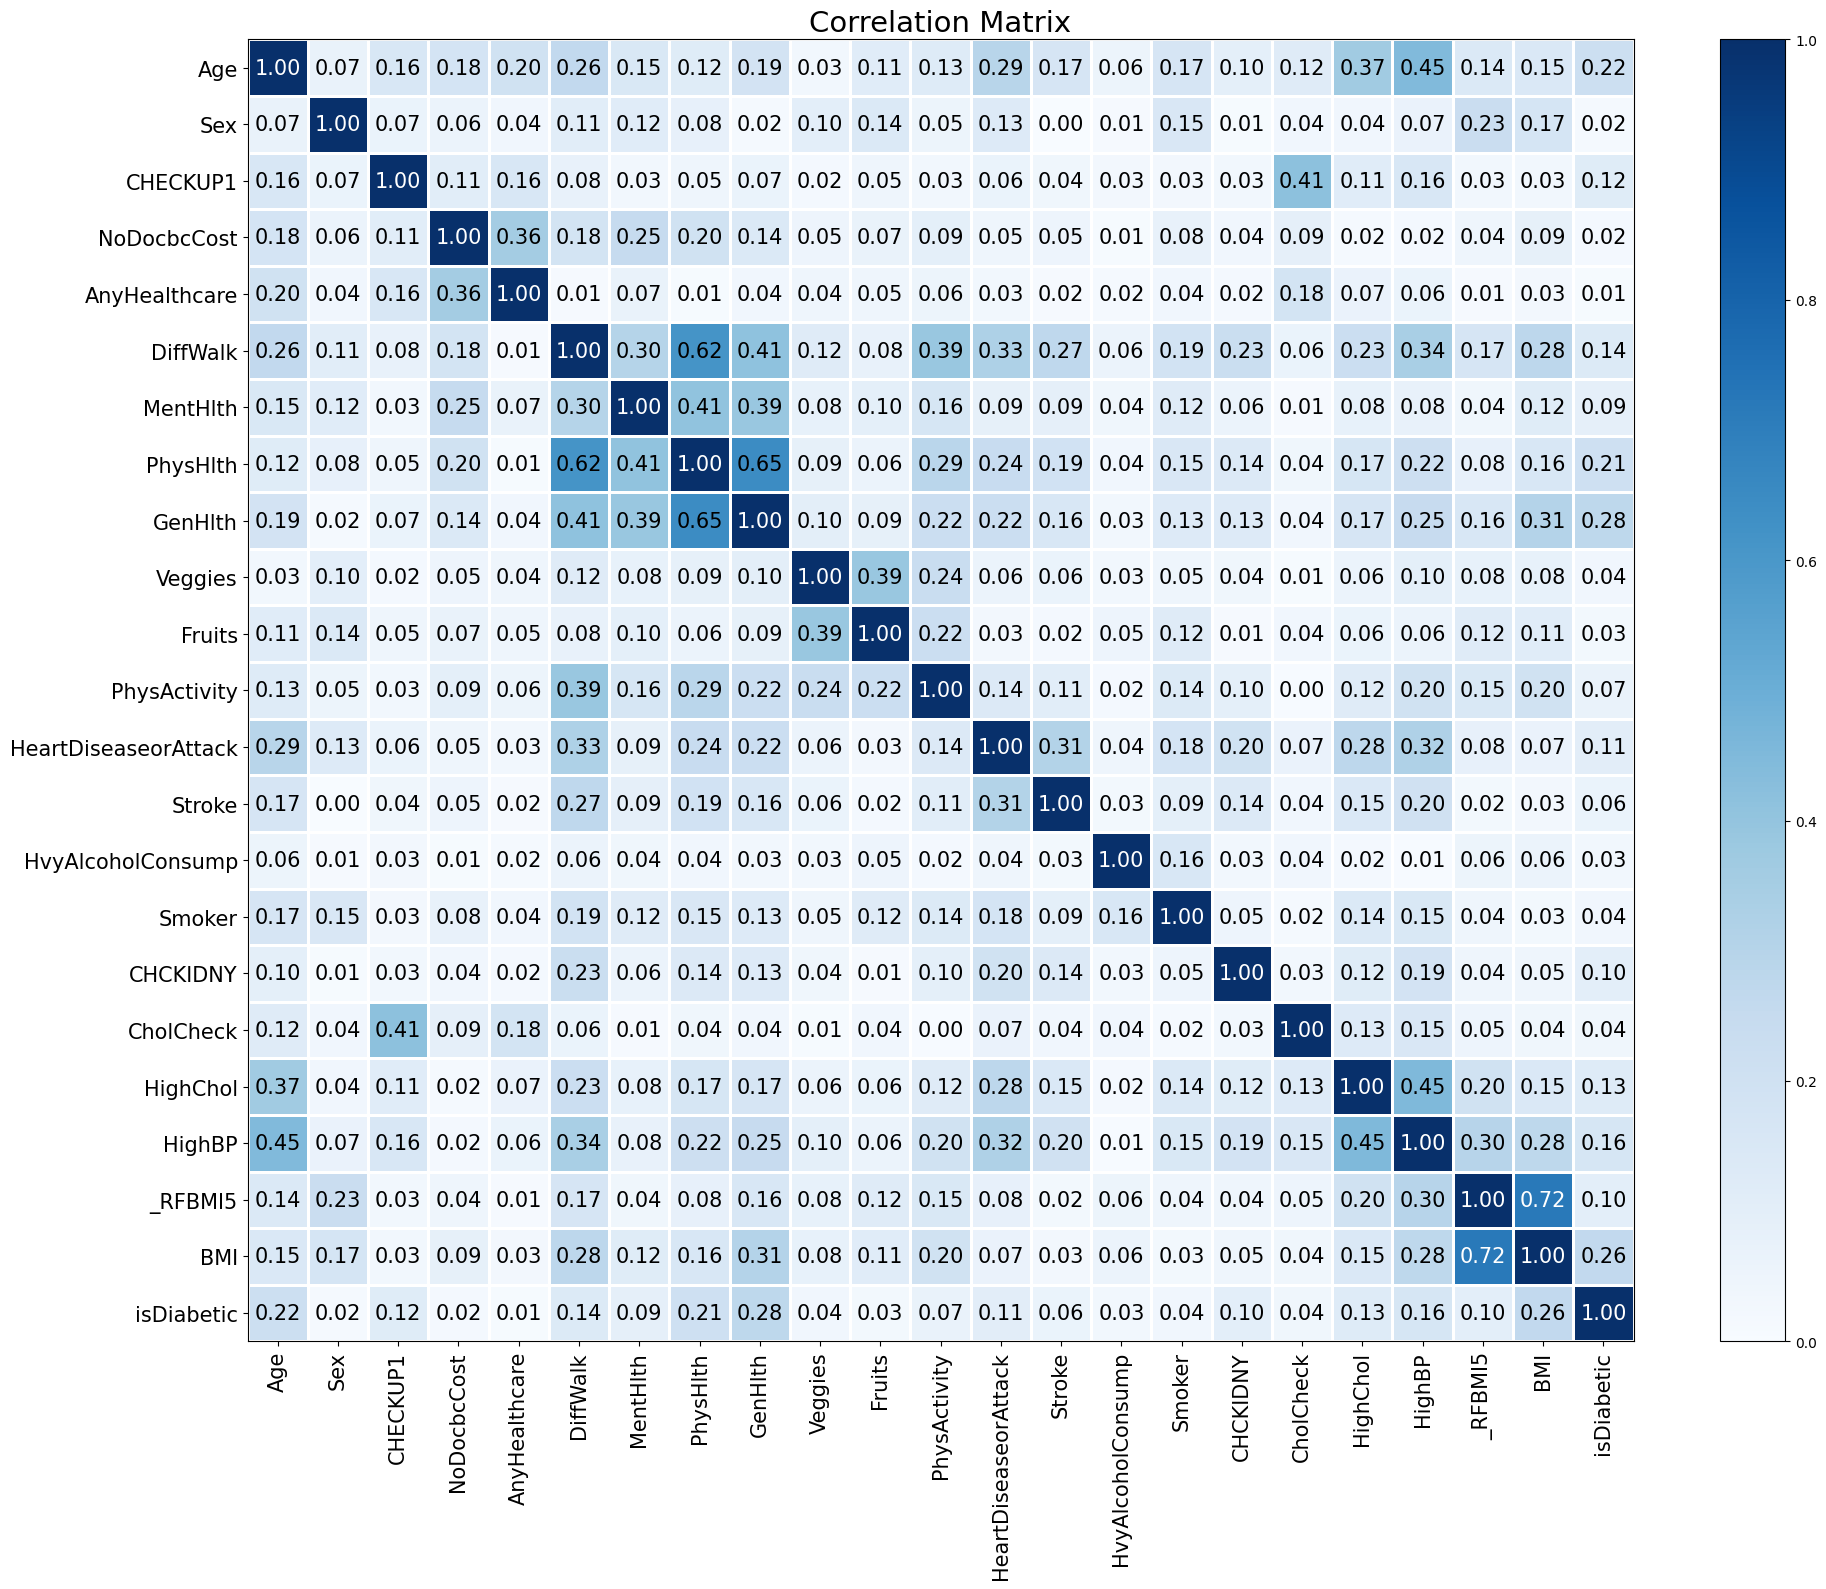

In [3]:
import phik
from phik.report import plot_correlation_matrix

corr_matrix = df.phik_matrix()
plot_correlation_matrix(
    corr_matrix.values,
    x_labels = corr_matrix.columns,
    y_labels = corr_matrix.index,
    vmin = 0,
    vmax = 1,
    color_map = "Blues",
    title = "Correlation Matrix",
    fontsize_factor = 1.5,
    figsize = (20, 16)
)

In [4]:
X = df.drop(labels=['isDiabetic'], axis=1)
y = df['isDiabetic']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

In [7]:
lr = LogisticRegression(
    class_weight='balanced', 
    max_iter=1000, 
    # multi_class='multinomial',
    solver='lbfgs',
    n_jobs=-1,
    random_state=42
)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print('LogReg Accuracy:', accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

/Users/other/Documents/Sweet-Sense-AI/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


LogReg Accuracy: 0.6400471796295012
              precision    recall  f1-score   support

         0.0       0.95      0.65      0.77     48332
         1.0       0.03      0.29      0.05      1097
         2.0       0.36      0.60      0.45      8223

    accuracy                           0.64     57652
   macro avg       0.45      0.52      0.43     57652
weighted avg       0.85      0.64      0.72     57652



/Users/other/Documents/Sweet-Sense-AI/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
model = XGBClassifier(
    objective='multi:softprob',
    # num_classes=3,
    max_depth=6,
    # min_child_weight=3,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    learning_rate=0.03,
    eval_metric='mlogloss',
    random_state=42,
    tree_method='hist',
    # gamma=2,
    # reg_alpha=1,
    # reg_lambda=2,
)
model.fit(X_train, y_train, sample_weight=sample_weights)
predictions = model.predict(X_test)
print('XGBoost Accuracy:', accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

XGBoost Accuracy: 0.6304377992090474
              precision    recall  f1-score   support

         0.0       0.95      0.64      0.76     48332
         1.0       0.03      0.31      0.06      1097
         2.0       0.36      0.64      0.46      8223

    accuracy                           0.63     57652
   macro avg       0.45      0.53      0.43     57652
weighted avg       0.85      0.63      0.71     57652



## Mutual Information

* Non-linear relationships, dependency between feature and target

In [14]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    X_train,
    y_train,
    random_state=42
)

mi_df = pd.DataFrame({
    'Feature': X_train.columns,
    'MI Score': mi_scores
})

mi_df = mi_df.sort_values(
    by='MI Score',
    ascending=False
)

print(mi_df)

                 Feature  MI Score
13               GenHlth  0.056110
2                 HighBP  0.053255
1                _RFBMI5  0.046185
10          PhysActivity  0.044351
17         AnyHealthcare  0.044242
4              CholCheck  0.043645
5               CHCKIDNY  0.039022
3               HighChol  0.037736
12               Veggies  0.037224
11                Fruits  0.036270
0                    BMI  0.031999
16              DiffWalk  0.023372
21                   Age  0.023121
6                 Smoker  0.021884
20                   Sex  0.020511
19              CHECKUP1  0.019496
14              PhysHlth  0.014615
9   HeartDiseaseorAttack  0.012381
8                 Stroke  0.004408
15              MentHlth  0.004154
7      HvyAlcoholConsump  0.002420
18           NoDocbcCost  0.001470


## Variance Inflation Factor

Detect multicollinearity, if two features are highly redundant, VIF becomes large

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()

vif_df["Feature"] = X_train.columns

vif_df["VIF"] = [
    variance_inflation_factor(X_train.values, i)
    for i in range(X_train.shape[1])
]

print(vif_df.sort_values(by="VIF", ascending=False))

                 Feature        VIF
0                    BMI  31.802260
5               CHCKIDNY  29.042421
4              CholCheck  24.522455
1                _RFBMI5  23.372613
17         AnyHealthcare  19.405614
13               GenHlth  10.860049
21                   Age  10.096398
12               Veggies   5.620805
10          PhysActivity   4.465034
19              CHECKUP1   3.119605
11                Fruits   3.035059
2                 HighBP   2.326607
3               HighChol   2.040050
14              PhysHlth   2.002501
6                 Smoker   1.916224
20                   Sex   1.881555
16              DiffWalk   1.807904
15              MentHlth   1.455199
9   HeartDiseaseorAttack   1.289870
18           NoDocbcCost   1.223548
8                 Stroke   1.124797
7      HvyAlcoholConsump   1.077164


## Tree based feature importance

In [16]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)

                 Feature  Importance
2                 HighBP    0.293902
13               GenHlth    0.138343
3               HighChol    0.070266
21                   Age    0.043846
16              DiffWalk    0.037527
1                _RFBMI5    0.036923
5               CHCKIDNY    0.035316
0                    BMI    0.035209
19              CHECKUP1    0.028074
18           NoDocbcCost    0.026928
9   HeartDiseaseorAttack    0.026675
7      HvyAlcoholConsump    0.026508
20                   Sex    0.023422
4              CholCheck    0.022617
15              MentHlth    0.020713
8                 Stroke    0.019890
14              PhysHlth    0.019803
17         AnyHealthcare    0.019418
6                 Smoker    0.018776
10          PhysActivity    0.018703
12               Veggies    0.018634
11                Fruits    0.018508


## SHAP

/Users/other/Documents/Sweet-Sense-AI/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


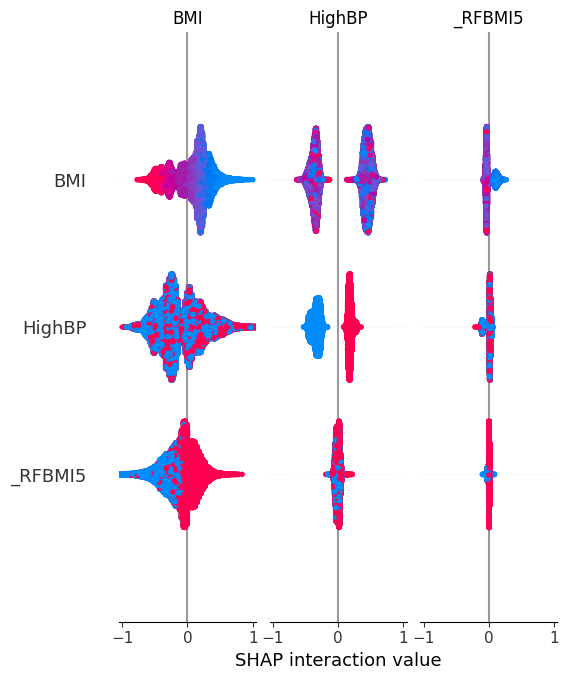

In [17]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)

## Cross-validated ablation

In [18]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, f1_score
from xgboost import XGBClassifier
import pandas as pd

macro_f1 = make_scorer(
    f1_score,
    average='macro'
)

baseline_model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42
)

baseline_score = cross_val_score(
    baseline_model,
    X_train,
    y_train,
    cv=5,
    scoring=macro_f1
).mean()

print("Baseline Macro F1:", baseline_score)

results = []

for feature in X_train.columns:

    X_temp = X_train.drop(columns=[feature])

    score = cross_val_score(
        baseline_model,
        X_temp,
        y_train,
        cv=5,
        scoring=macro_f1
    ).mean()

    results.append({
        'Removed Feature': feature,
        'Macro F1': score,
        'Drop': baseline_score - score
    })

ablation_df = pd.DataFrame(results)

ablation_df = ablation_df.sort_values(
    by='Drop',
    ascending=False
)

print(ablation_df)

Baseline Macro F1: 0.40259707246232707
         Removed Feature  Macro F1      Drop
13               GenHlth  0.391367  0.011230
0                    BMI  0.391465  0.011132
3               HighChol  0.395706  0.006891
21                   Age  0.395819  0.006778
2                 HighBP  0.397337  0.005260
9   HeartDiseaseorAttack  0.400153  0.002444
5               CHCKIDNY  0.400469  0.002129
19              CHECKUP1  0.400646  0.001951
20                   Sex  0.400664  0.001934
16              DiffWalk  0.400974  0.001623
10          PhysActivity  0.401636  0.000961
7      HvyAlcoholConsump  0.401715  0.000882
6                 Smoker  0.401746  0.000851
18           NoDocbcCost  0.401881  0.000716
14              PhysHlth  0.401995  0.000602
1                _RFBMI5  0.402032  0.000565
11                Fruits  0.402130  0.000467
17         AnyHealthcare  0.402135  0.000462
4              CholCheck  0.402192  0.000405
12               Veggies  0.402532  0.000065
15              

## Inference

Dominant features: BMI, HighBP, Age, HighChol
Derived variables: _RFBMI5, CholCheck, AnyHealthcare
Noisy features: Stroke, MentHlth

Features to remove: _RFBMI5, Stroke, MentHlth

In [25]:
df.drop(labels=["_RFBMI5", "Stroke", "MentHlth"], axis=1)
df.head()

,isDiabetic,BMI,_RFBMI5,HighBP,HighChol,CholCheck,CHCKIDNY,Smoker,HvyAlcoholConsump,Stroke,...,Veggies,GenHlth,PhysHlth,MentHlth,DiffWalk,AnyHealthcare,NoDocbcCost,CHECKUP1,Sex,Age
0,0.0,40.0,2.0,1.0,1.0,1.0,2.0,1.0,0.0,0.0,...,1.0,5.0,15.0,18.0,1.0,1.0,0.0,1.0,0.0,9.0
1,0.0,25.0,2.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,...,0.0,3.0,0.0,0.0,0.0,0.0,1.0,4.0,0.0,7.0
2,0.0,28.0,2.0,1.0,1.0,1.0,2.0,0.0,0.0,0.0,...,0.0,5.0,30.0,30.0,1.0,1.0,1.0,1.0,0.0,9.0
3,0.0,27.0,2.0,1.0,0.0,1.0,2.0,0.0,0.0,0.0,...,1.0,2.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,11.0
4,0.0,24.0,1.0,1.0,1.0,1.0,2.0,0.0,0.0,0.0,...,1.0,2.0,0.0,3.0,0.0,1.0,0.0,1.0,0.0,11.0


In [38]:
df.columns

Index(['isDiabetic', 'BMI', '_RFBMI5', 'HighBP', 'HighChol', 'CholCheck',
       'CHCKIDNY', 'Smoker', 'HvyAlcoholConsump', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'GenHlth',
       'PhysHlth', 'MentHlth', 'DiffWalk', 'AnyHealthcare', 'NoDocbcCost',
       'CHECKUP1', 'Sex', 'Age'],
      dtype='str')

In [29]:
X = df.drop(labels=['isDiabetic'], axis=1)
y = df['isDiabetic']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

In [32]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
model = XGBClassifier(
    objective='multi:softprob',
    # num_classes=3,
    max_depth=6,
    # min_child_weight=3,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    learning_rate=0.03,
    eval_metric='mlogloss',
    random_state=42,
    tree_method='hist',
    # gamma=2,
    # reg_alpha=1,
    # reg_lambda=2,
)
model.fit(
    X_train, 
    y_train, 
    eval_set=[(X_val, y_val)], 
    # early_stopping_rounds=30,
    sample_weight=sample_weights,
    verbose=False
)
predictions = model.predict(X_test)
print('XGBoost Accuracy:', accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

XGBoost Accuracy: 0.6345428895210342
              precision    recall  f1-score   support

         0.0       0.96      0.64      0.77     36363
         1.0       0.03      0.26      0.05       803
         2.0       0.36      0.65      0.46      6073

    accuracy                           0.63     43239
   macro avg       0.45      0.52      0.43     43239
weighted avg       0.85      0.63      0.71     43239



# Data Imbalance

In [33]:
import numpy as np


val_probs = model.predict_proba(X_val)

def custom_predict(probs, thresh_class1=0.25, thresh_class2=0.40):

    preds = []

    for p in probs:

        # Class 1 threshold
        if p[1] >= thresh_class1:
            preds.append(1)

        # Class 2 threshold
        elif p[2] >= thresh_class2:
            preds.append(2)

        # Otherwise majority class
        else:
            preds.append(0)

    return np.array(preds)


In [34]:
from sklearn.metrics import classification_report, f1_score

val_preds = custom_predict(val_probs, thresh_class1=0.20, thresh_class2=0.35)
print(classification_report(y_val, val_preds))
print("Macro F1:", f1_score(y_val, val_preds, average='macro'))

              precision    recall  f1-score   support

         0.0       0.98      0.33      0.50     36363
         1.0       0.02      0.92      0.05       802
         2.0       0.49      0.07      0.13      6074

    accuracy                           0.31     43239
   macro avg       0.50      0.44      0.22     43239
weighted avg       0.90      0.31      0.44     43239

Macro F1: 0.224104947713593


In [35]:
best_f1 = 0
best_t1 = 0
best_t2 = 0

for t1 in np.arange(0.10, 0.60, 0.05):

    for t2 in np.arange(0.10, 0.60, 0.05):

        preds = custom_predict(
            val_probs,
            thresh_class1=t1,
            thresh_class2=t2
        )

        score = f1_score(
            y_val,
            preds,
            average='macro'
        )

        if score > best_f1:

            best_f1 = score
            best_t1 = t1
            best_t2 = t2

print("Best Macro F1:", best_f1)
print("Best Threshold Class 1:", best_t1)
print("Best Threshold Class 2:", best_t2)

Best Macro F1: 0.46210077555610757
Best Threshold Class 1: 0.4500000000000001
Best Threshold Class 2: 0.4500000000000001


In [36]:
test_probs = model.predict_proba(X_test)

test_preds = custom_predict(
    test_probs,
    thresh_class1=best_t1,
    thresh_class2=best_t2
)

print(classification_report(y_test, test_preds))

print(
    "Final Macro F1:",
    f1_score(y_test, test_preds, average='macro')
)

              precision    recall  f1-score   support

         0.0       0.91      0.85      0.88     36363
         1.0       0.03      0.07      0.04       803
         2.0       0.42      0.51      0.46      6073

    accuracy                           0.79     43239
   macro avg       0.45      0.48      0.46     43239
weighted avg       0.82      0.79      0.81     43239

Final Macro F1: 0.46134006173283965


In [37]:
model.save_model('/Users/other/Documents/Sweet-Sense-AI/model/prepared_model.json')